# Unsupervised Machine Learning: Automated Coastline Extraction

**Objective:** Deploy an unsupervised machine learning algorithm to automatically classify land and water and extract coastal boundaries along Boambee Creek, NSW.
*   **The Problem:** Manually digitising coastlines to track erosion, estuarine phase shifts, or mangrove inundation is extremely time-consuming and prone to human bias. Standard optical indices often misclassify dark urban asphalt as water.
*   **The Solution:** This pipeline calculates the Modified Normalised Difference Water Index (MNDWI) from Sentinel-2 imagery, replacing Near-Infrared with Short-Wave Infrared (SWIR) to reduce urban noise. It then applies Otsu’s Method to dynamically classify water pixels, followed by Morphological Filtering to remove residual urban shadows and noise.
*   **Key Libraries:** `scikit-image`, `xarray`, `pystac-client`, `odc-stac`
---
*   **Author:** Jade Farrugia | Marine Biogeochemical Modeller & PhD Candidate
*   **Contact:** https://www.linkedin.com/in/jadefarrugia/
*   **Date:** August 2026

In [1]:
import pystac_client
import planetary_computer
import odc.stac
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects

print("Querying Sentinel-2 over Boambee Creek, NSW...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Boambee Creek Bounding Box
bbox = [153.08, -30.35, 153.12, -30.32] 

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-01-01/2026-01-01",
    query={"eo:cloud_cover": {"lt": 5}}
)
items = list(search.items())

# Lazy-load Green (B03) and SWIR (B11) bands required for MNDWI
data = odc.stac.stac_load(
    [items[0]], # Grab the clearest recent image
    bands=["B03", "B11"], 
    bbox=bbox,
    resolution=10,
    chunks={"x": 1024, "y": 1024}
).isel(time=0)

print("Data loaded successfully.")

Querying Sentinel-2 over Boambee Creek, NSW...
Data loaded successfully.


Algorithm successfully determined dynamic water threshold at MNDWI = -0.083


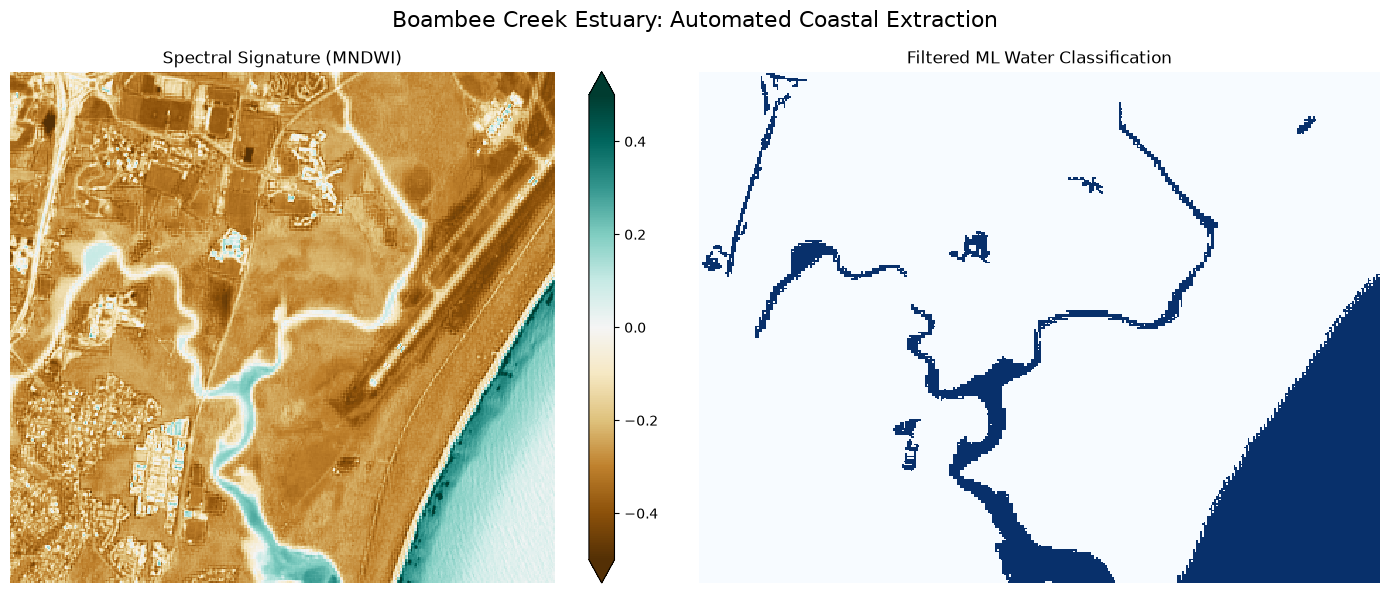

In [2]:
# 1. Calculate MNDWI
mndwi = (data.B03 - data.B11) / (data.B03 + data.B11)

# 2. Extract values for Machine Learning 
mndwi_values = mndwi.compute().values
clean_mndwi = mndwi_values[~np.isnan(mndwi_values)]

# 3. Unsupervised ML: Otsu's Thresholding
otsu_thresh = threshold_otsu(clean_mndwi)
print(f"Algorithm successfully determined dynamic water threshold at MNDWI = {otsu_thresh:.3f}")

# 4. Apply the classification mask
raw_water_mask = (mndwi > otsu_thresh).compute().values

# Morphological Filtering
clean_water_array = remove_small_objects(raw_water_mask, max_size=50)

# Convert the clean numpy array back to an xarray DataArray for mapping
clean_water_mask = xr.DataArray(clean_water_array, coords=mndwi.coords, dims=mndwi.dims)

# 5. Visualise the Phase-Shift
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

mndwi.plot.imshow(ax=ax1, cmap="BrBG", vmin=-0.5, vmax=0.5)
ax1.set_title("Spectral Signature (MNDWI)")
ax1.axis('off')

clean_water_mask.plot.imshow(ax=ax2, cmap="Blues", add_colorbar=False)
ax2.set_title("Filtered ML Water Classification")
ax2.axis('off')

plt.suptitle("Boambee Creek Estuary: Automated Coastal Extraction", fontsize=16)
plt.tight_layout()
plt.show()